## Import Library
import an library that require on this lab

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset
load the dataset 

In [165]:
df = pd.read_csv("dataset.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Dataset Overview
inspect dataset before proceed

In [166]:
df.info()

df.describe()

df["sex"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


sex
male      676
female    662
Name: count, dtype: int64

## Data Exploration
explore patterns and distributions

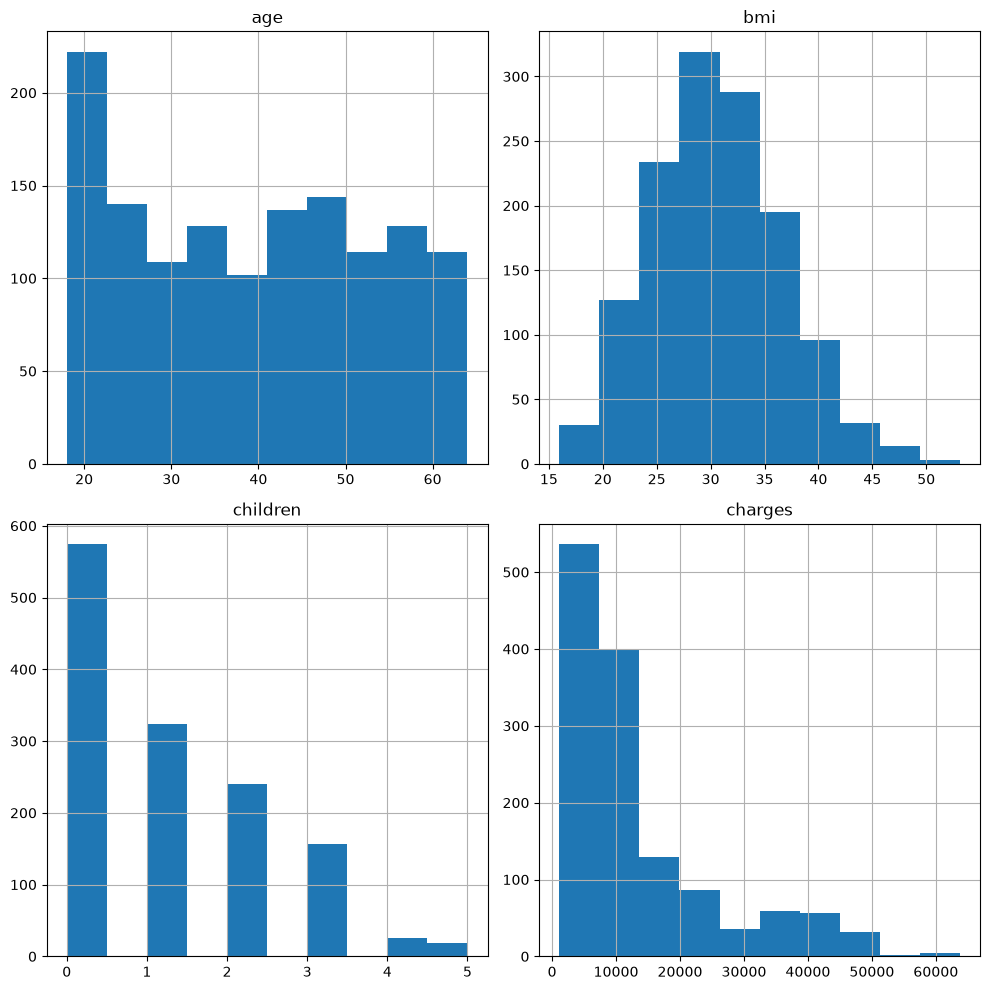

In [167]:
df.hist(figsize=(10,10))
plt.tight_layout()
plt.show()

##  Feature Selection
select the most relevant features for model training

In [168]:
X = df.drop("sex", axis=1)
y = df["sex"]

## Split Dataset
split data into training and testing sets

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Standardize Features
scale numeric features using StandardScaler

In [170]:
y = (df["sex"] == "male").astype(
    int
)
X = df.drop(columns=["sex"])

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train KNN Model and Compare Accuracy
train model using common k values and then compare accurasion

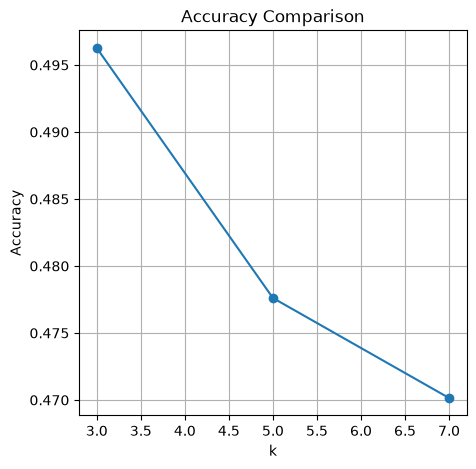

In [171]:
k_values = [3, 5, 7,]
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results.append([k, acc])

results_df = pd.DataFrame(results, columns=["k", "Accuracy"])
results_df

plt.figure(figsize=(5,5))

plt.plot(results_df["k"], results_df["Accuracy"], marker="o")

plt.xlabel("k")

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.grid(True)

plt.show()


# The Best K Value
find the best k value with highest accuracy

In [172]:
best_row = results_df.loc[results_df["Accuracy"].idxmax()]

print(f"Best k: {int(best_row['k'])}")
print(f"Highest Accuracy: {best_row['Accuracy']:.4f}")

Best k: 3
Highest Accuracy: 0.4963


# Confusion Matrix
evaluate the best model by visualizing correct and incorrect predictions

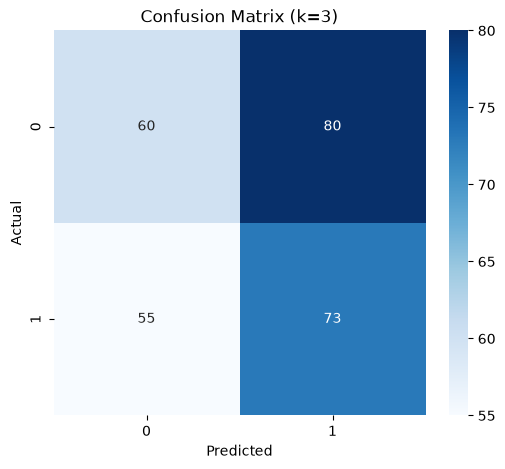

In [173]:
best_k = int(results_df.loc[results_df["Accuracy"].idxmax()]["k"])
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()

## Classification Report
display detailed evaluation metrics including precision, recall, and F1-score

In [174]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.43      0.47       140
           1       0.48      0.57      0.52       128

    accuracy                           0.50       268
   macro avg       0.50      0.50      0.50       268
weighted avg       0.50      0.50      0.49       268

